# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sk
import numpy as np
import warnings

from pyexpat.errors import XML_ERROR_TEXT_DECL

warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('ec2_cpu_utilization_24ae8d.csv')
df.head()

,timestamp,value
0,2014-02-14 14:30:00,0.132
1,2014-02-14 14:35:00,0.134
2,2014-02-14 14:40:00,0.134
3,2014-02-14 14:45:00,0.134
4,2014-02-14 14:50:00,0.134


In [5]:
anomalies_timestamp = ["2014-02-26 22:05:00",
        "2014-02-27 17:15:00"]

In [6]:
#convertimp in format cu timp

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head()

,timestamp,value
0,2014-02-14 14:30:00,0.132
1,2014-02-14 14:35:00,0.134
2,2014-02-14 14:40:00,0.134
3,2014-02-14 14:45:00,0.134
4,2014-02-14 14:50:00,0.134


In [7]:
# Adaugam eticheta de anomalie
# punct normal = 1 , outlier = -1 (pt scikitlearning)
df['is_anomaly'] = 1


#cauta in df elem cu val de pe col timestamp == elementul curent din lista
#si modifica acest parametru = -1 (outlier in libraria scikit - learn)

for each in anomalies_timestamp:
    df.loc[df['timestamp'] == each, 'is_anomaly'] = -1

df.head()


,timestamp,value,is_anomaly
0,2014-02-14 14:30:00,0.132,1
1,2014-02-14 14:35:00,0.134,1
2,2014-02-14 14:40:00,0.134,1
3,2014-02-14 14:45:00,0.134,1
4,2014-02-14 14:50:00,0.134,1


In [8]:
anomaly_df = df.loc[df['is_anomaly'] == -1]
inlier_df = df.loc[df['is_anomaly'] == 1]


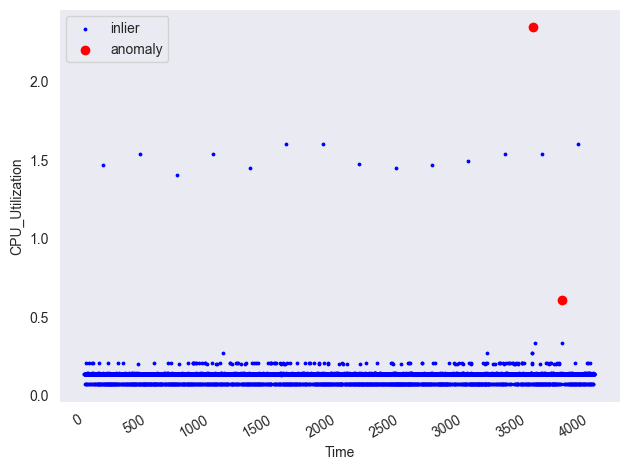

In [9]:
fig, ax = plt.subplots()

ax.scatter(inlier_df.index, inlier_df['value'], color = 'blue', s = 3, label = 'inlier')
ax.scatter(anomaly_df.index, anomaly_df['value'], color = 'red',label = 'anomaly')
ax.set_xlabel('Time')
ax.set_ylabel('CPU_Utilization')
ax.legend(loc = 2)

plt.grid(False)
fig.autofmt_xdate()
plt.tight_layout()

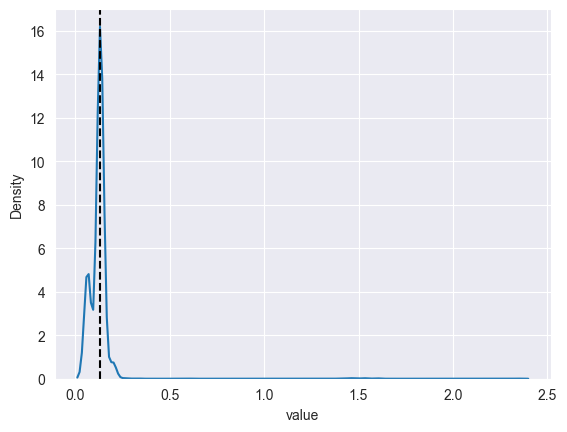

In [10]:
import seaborn as sns

sns.kdeplot(df['value'])
plt.axvline(0.134,0,1,c = 'black',ls = '--')
#majoritatea val cade pe mediana -> MAD nu o sa functioneze foarte bine

In [11]:
from scipy.stats import median_abs_deviation

mad = median_abs_deviation(df['value'])
median = np.median(df['value'])

print(mad)
print(median)

def calc_z_score(x):
    return 0.6745 * (x - median)/mad

0.0020000000000000018
0.134


In [12]:
#Calc z score pentru toate elem

df['z_score'] = df['value'].apply(calc_z_score)

df.head()

,timestamp,value,is_anomaly,z_score
0,2014-02-14 14:30:00,0.132,1,-0.6745
1,2014-02-14 14:35:00,0.134,1,0.0000
2,2014-02-14 14:40:00,0.134,1,0.0000
3,2014-02-14 14:45:00,0.134,1,0.0000
4,2014-02-14 14:50:00,0.134,1,0.0000


In [13]:
#Determinare daca este sau nu o anomalie

df['base'] = 1

df.loc[df['z_score'] > 3.5, 'base'] = -1
df.loc[df['z_score'] <= -3.5, 'base'] = -1


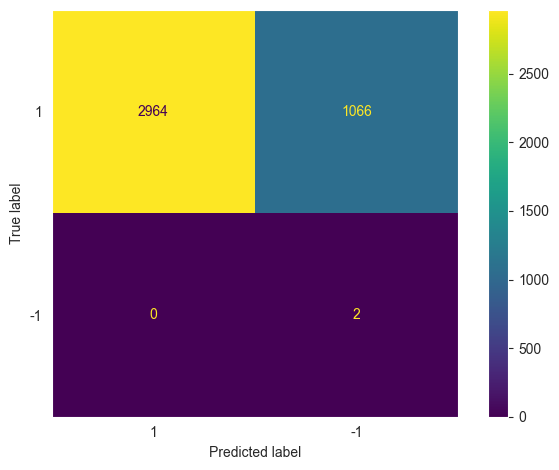

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(df['is_anomaly'], df['base'],labels = [1,-1])
disp_cm = ConfusionMatrixDisplay(cm, display_labels=[1,-1])
disp_cm.plot()
plt.grid(False)
plt.tight_layout()


In [15]:
from sklearn.ensemble import IsolationForest

train = df[:3550]
test = df[3550:]

contaminare = 1/len(train)

iso_forest = IsolationForest(contamination = contaminare, random_state = 42)
X_train = train['value'].values.reshape(-1,1)
iso_forest.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.00028169014084507044
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [16]:
pred_iso_forest = iso_forest.predict(test['value'].values.reshape(-1,1))

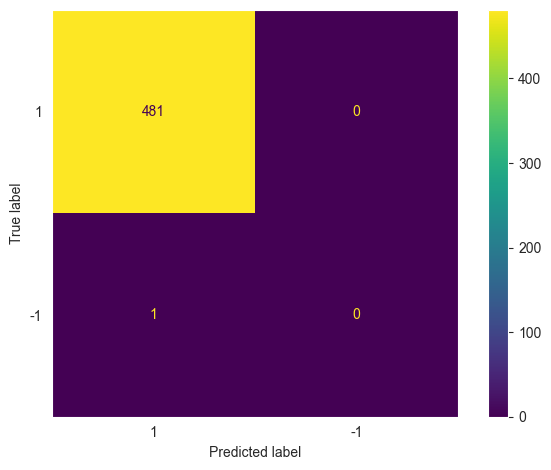

In [19]:
cm = confusion_matrix(test['is_anomaly'], pred_iso_forest,labels = [1,-1])
disp_cm = ConfusionMatrixDisplay(cm, display_labels=[1,-1])
disp_cm.plot()
plt.grid(False)
plt.tight_layout()

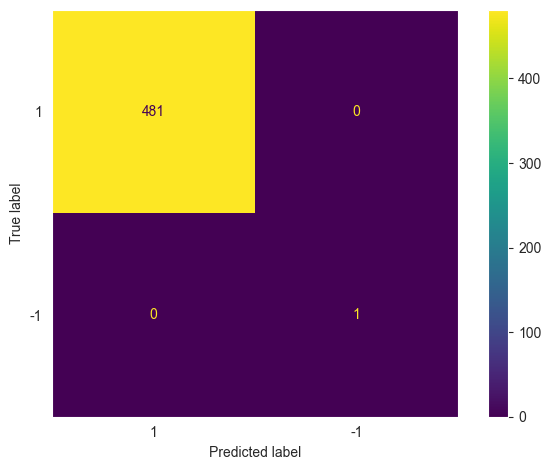

In [22]:
#Local outlier factor
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(contamination = contaminare,novelty = True)
lof.fit(X_train)
preds_lof = lof.predict(test['value'].values.reshape(-1,1))

cm = confusion_matrix(test['is_anomaly'], preds_lof,labels = [1,-1])
disp_cm = ConfusionMatrixDisplay(cm, display_labels=[1,-1])
disp_cm.plot()
plt.grid(False)
plt.tight_layout()
